In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
# LOAD DATASET
import pandas as pd

data = pd.read_csv("Superstore.csv", encoding="ISO-8859-1")


In [3]:
# Date conversion
import matplotlib.pyplot as plt
data["Order Date"] = pd.to_datetime(data["Order Date"], dayfirst=True)
data["Ship Date"] = pd.to_datetime(data["Ship Date"], dayfirst=True)

# New columns
data["Delivery Time"] = (data["Ship Date"] - data["Order Date"]).dt.days
data["Order Year"] = data["Order Date"].dt.year
data["Order Month"] = data["Order Date"].dt.month

print("Dataset Loaded Successfully")
print(data.head())

Dataset Loaded Successfully
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

          Category  Sub-Category  \
0        Furniture     Bookcases   
1   

Profit Margin by Category and Sub-Category
                                    Sales      Profit  Profit Margin
Category        Sub-Category                                        
Furniture       Bookcases     114879.9963  -3472.5560      -3.022768
                Chairs        328449.1030  26590.1663       8.095673
                Furnishings    91705.1640  13059.1436      14.240358
                Tables        206965.5320 -17725.4811      -8.564460
Office Supplies Appliances    107532.1610  18138.0054      16.867517
                Art            27118.7920   6527.7870      24.071083
                Binders       203412.7330  30221.7633      14.857361
                Envelopes      16476.4020   6964.1767      42.267582
                Fasteners       3024.2800    949.5182      31.396504
                Labels         12486.3120   5546.2540      44.418672
                Paper          78479.2060  34053.5693      43.391837
                Storage       223843.6080  21278.8264       

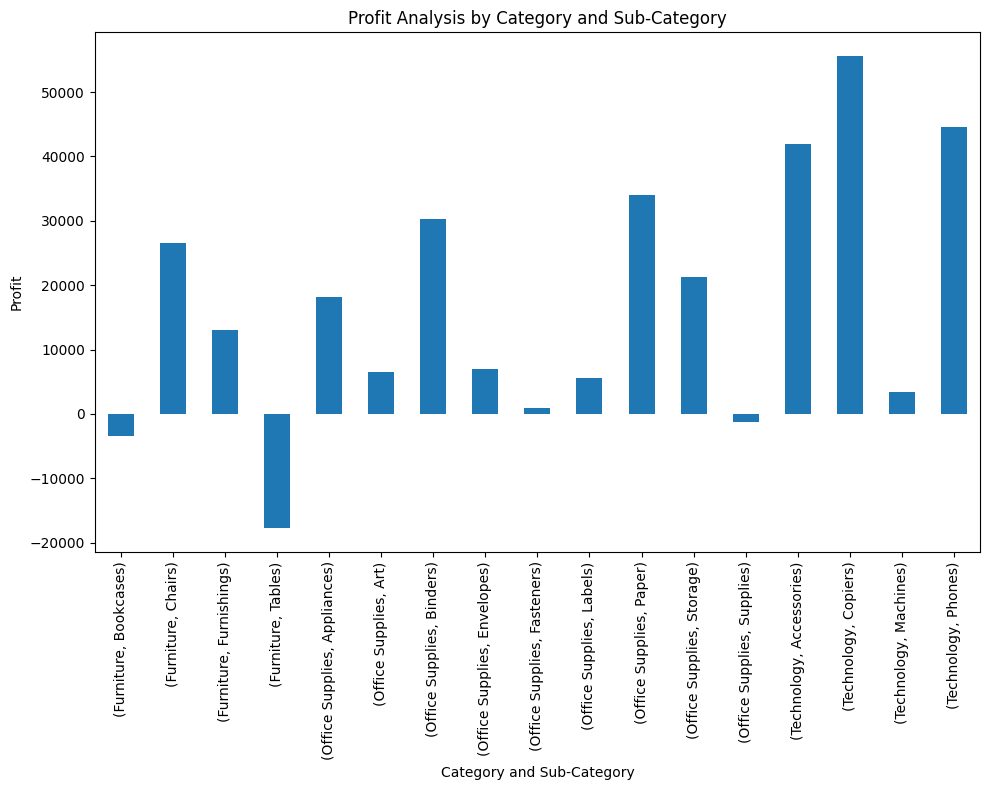

In [4]:
# Question 1: Profit analysis by category and sub-category

category_profit = data.groupby(['Category', 'Sub-Category'])[['Sales', 'Profit']].sum()

category_profit['Profit Margin'] = (category_profit['Profit'] / category_profit['Sales']) * 100

print("Profit Margin by Category and Sub-Category")
print(category_profit)

plt.figure(figsize=(10,8))
category_profit['Profit'].plot(kind='bar')
plt.title('Profit Analysis by Category and Sub-Category')
plt.xlabel('Category and Sub-Category')
plt.ylabel('Profit')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


2. Region Wise Performance
               Sales       Profit
Region                           
Central  501239.8908   39706.3625
East     678781.2400   91522.7800
South    391721.9050   46749.4303
West     725457.8245  108418.4489
               Sales       Profit
Region                           
West     725457.8245  108418.4489
East     678781.2400   91522.7800
Central  501239.8908   39706.3625
South    391721.9050   46749.4303


<Figure size 1200x600 with 0 Axes>

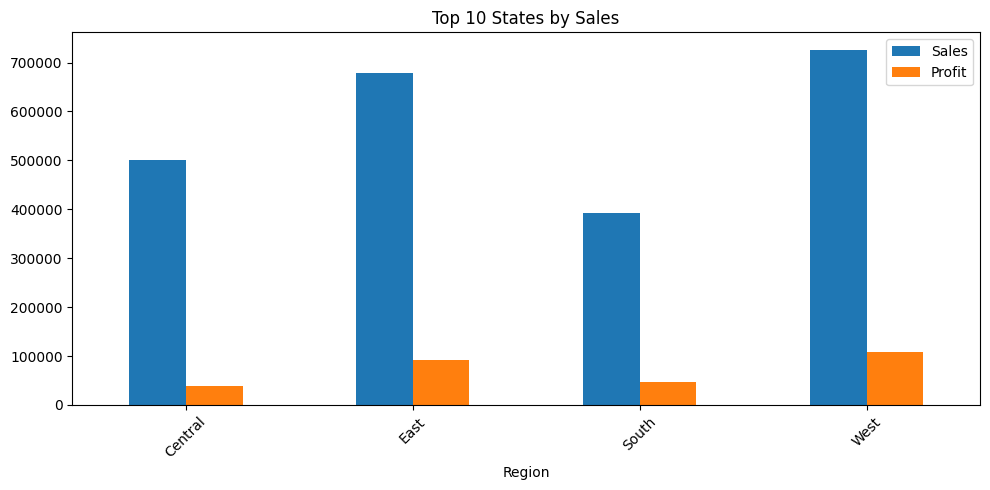

In [5]:
# QUESTION 2: Region wise sales and profit
region_data = data.groupby("Region")[["Sales", "Profit"]].sum()
print("\n2. Region Wise Performance")
print(region_data)

print(region_data.sort_values(by='Sales', ascending=False).head())
plt.figure(figsize=(12, 6))
top_states = region_data.sort_values(by='Sales', ascending=False).head(10)
region_data.plot(kind='bar', figsize=(10,5))
plt.title('Top 10 States by Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Discount vs Average Profit
Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64


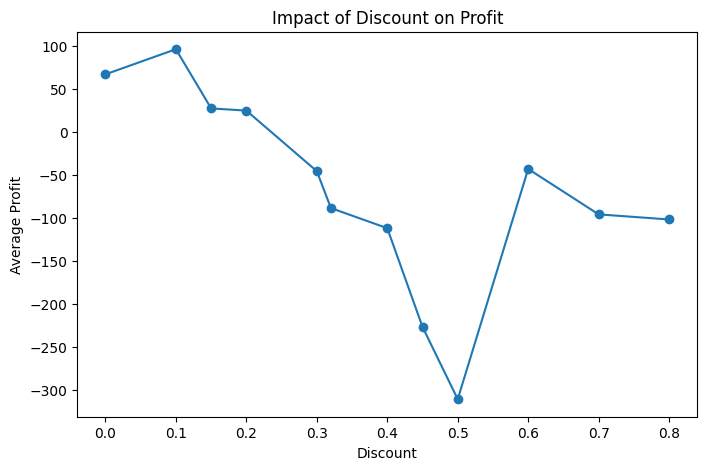

In [6]:
# QUESTION 3: Discount effect on profit
discount_profit = data.groupby("Discount")["Profit"].mean()
print("\nDiscount vs Average Profit")
print(discount_profit)

discount_profit.plot(marker="o", figsize=(8, 5))
plt.title("Impact of Discount on Profit")
plt.ylabel("Average Profit")
plt.show()

In [7]:
# QUESTION 4: Products making losses
loss_items = data.groupby("Product Name")[["Sales", "Profit"]].sum()
loss_items = loss_items[loss_items["Profit"] < 0].sort_values("Profit").head(10)

print("\nTop Loss Making Products")
print(loss_items)


Top Loss Making Products
                                                        Sales     Profit
Product Name                                                            
Cubify CubeX 3D Printer Double Head Print           11099.963 -8879.9704
Lexmark MX611dhe Monochrome Laser Printer           16829.901 -4589.9730
Cubify CubeX 3D Printer Triple Head Print            7999.980 -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Table...   9917.640 -2876.1156
Bush Advantage Collection Racetrack Conference ...   9544.725 -1934.3976
GBC DocuBind P400 Electric Binding System           17965.068 -1878.1662
Cisco TelePresence System EX90 Videoconferencin...  22638.480 -1811.0784
Martin Yale Chadless Opener Electric Letter Opener  16656.200 -1299.1836
Balt Solid Wood Round Tables                         6518.754 -1201.0581
BoxOffice By Design Rectangular and Half-Moon M...   1706.250 -1148.4375



Average Delivery Time
Ship Mode
First Class       2.182705
Same Day          0.044199
Second Class      3.238046
Standard Class    5.006535
Name: Delivery Time, dtype: float64


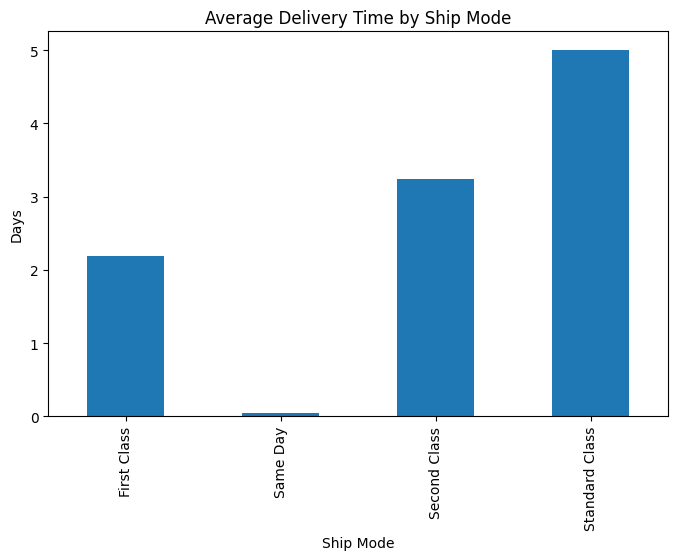

In [8]:
# QUESTION 5: Average shipping time by mode
shipping_avg = data.groupby("Ship Mode")["Delivery Time"].mean()
print("\nAverage Delivery Time")
print(shipping_avg)

shipping_avg.plot(kind="bar", figsize=(8, 5))
plt.title("Average Delivery Time by Ship Mode")
plt.ylabel("Days")
plt.show()

In [9]:
# QUESTION 6: Shipping mode profitability


ship_profit = data.groupby("Ship Mode")[["Sales", "Profit"]].sum()
print("\nShipping Mode Profitability")
print(ship_profit)


Shipping Mode Profitability
                       Sales       Profit
Ship Mode                                
First Class     3.514284e+05   48969.8399
Same Day        1.283631e+05   15891.7589
Second Class    4.591936e+05   57446.6354
Standard Class  1.358216e+06  164088.7875


In [10]:
# QUESTION 7: Shipping performance by region

region_ship = data.groupby(["Region", "Ship Mode"])[["Sales", "Profit"]].sum()
print("\nRegion + Ship Mode Analysis")
print(region_ship)


Region + Ship Mode Analysis
                              Sales      Profit
Region  Ship Mode                              
Central First Class      58746.9154   3707.2672
        Same Day         20415.4100   1531.8797
        Second Class    103550.0054   9114.8349
        Standard Class  318527.5600  25352.3807
East    First Class     113587.0530  15732.0141
        Same Day         43326.8320   7980.2670
        Second Class    116545.5240  10787.2908
        Standard Class  405321.8310  57023.2081
South   First Class      49332.5660   6892.3854
        Same Day         21017.1730  -1762.3350
        Second Class     93758.6125  14667.1469
        Standard Class  227613.5535  26952.2330
West    First Class     129761.8885  22638.1732
        Same Day         43603.7100   8141.9472
        Second Class    145339.4275  22877.3628
        Standard Class  406752.7985  54760.9657


In [11]:
# QUESTION 8: Customer segment average order value

segment_sales = data.groupby("Segment")["Sales"].mean()
print("\nAverage Order Value by Segment")
print(segment_sales)


Average Order Value by Segment
Segment
Consumer       223.733644
Corporate      233.823300
Home Office    240.972041
Name: Sales, dtype: float64


In [12]:
# QUESTION 9: Top profitable customers

best_customers = data.groupby("Customer Name")["Profit"].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Profitable Customers")
print(best_customers)



Top 10 Profitable Customers
Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64


In [13]:
# QUESTION 10: Repeat customer analysis

repeat_customer = data.groupby("Customer ID").agg({
    "Order ID": "count",
    "Profit": "sum",
    "Discount": "mean"
})

print("\nRepeat Purchase Analysis")
print(repeat_customer.head())


Repeat Purchase Analysis
             Order ID    Profit  Discount
Customer ID                              
AA-10315           11 -362.8825  0.090909
AA-10375           15  277.3824  0.080000
AA-10480           12  435.8274  0.016667
AA-10645           18  857.8033  0.063889
AB-10015            6  129.3465  0.066667



Yearly Trend
                              Sales      Profit  Discount
Order Year Order Month                                   
2014       1             14236.8950   2450.1907     10.00
           2              4519.8920    862.3084      8.10
           3             55691.0090    498.7299     26.30
           4             28295.3450   3488.8352     14.85
           5             23648.2870   2738.7096     18.95
           6             34595.1276   4976.5244     23.22
           7             33946.3930   -841.4826     24.55
           8             27909.4685   5318.1050     20.05
           9             81777.3508   8328.0994     42.87
           10            31453.3930   3448.2573     25.45
           11            78628.7167   9292.1269     48.07
           12            69545.6205   8983.5699     53.05
2015       1             18174.0756  -3281.0070     10.32
           2             11951.4110   2813.8508      8.30
           3             38726.2520   9732.0978     19.34


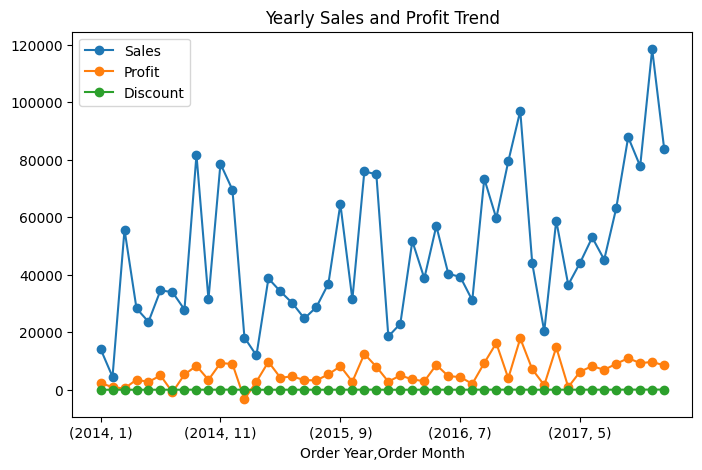

In [14]:
# QUESTION 11:Monthly sales, profit, and discount trends

yearly_data = data.groupby(["Order Year", "Order Month"])[["Sales", "Profit","Discount"]].sum()
print("\nYearly Trend")
print(yearly_data)

yearly_data.plot(marker="o", figsize=(8, 5))
plt.title("Yearly Sales and Profit Trend")
plt.show()


Monthly Sales
Order Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64


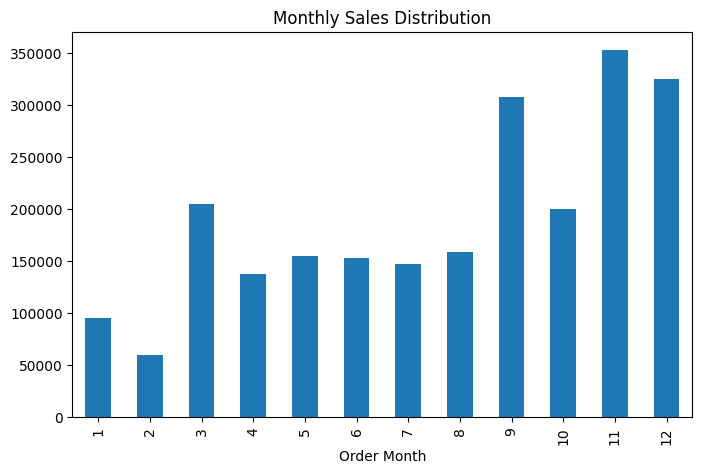

In [15]:
# QUESTION 12: Monthly peak sales

monthly_data = data.groupby("Order Month")["Sales"].sum()
print("\nMonthly Sales")
print(monthly_data)

monthly_data.plot(kind="bar", figsize=(8, 5))
plt.title("Monthly Sales Distribution")
plt.show()

In [16]:
# QUESTION 13: Sales per quantity

subcategory_ratio = data.groupby("Sub-Category")[["Sales", "Quantity"]].sum()
subcategory_ratio["Sales per Quantity"] = (
    subcategory_ratio["Sales"] / subcategory_ratio["Quantity"]
)

print("\nSales per Quantity")
print(subcategory_ratio.sort_values("Sales per Quantity", ascending=False))


Sales per Quantity
                    Sales  Quantity  Sales per Quantity
Sub-Category                                           
Copiers       149528.0300       234          639.008675
Machines      189238.6310       440          430.087798
Tables        206965.5320      1241          166.773193
Chairs        328449.1030      2356          139.409636
Bookcases     114879.9963       868          132.350226
Phones        330007.0540      3289          100.336593
Supplies       46673.5380       647           72.138389
Storage       223843.6080      3158           70.881446
Appliances    107532.1610      1729           62.193268
Accessories   167380.3180      2976           56.243386
Binders       203412.7330      5974           34.049671
Furnishings    91705.1640      3563           25.738188
Envelopes      16476.4020       906           18.185874
Paper          78479.2060      5178           15.156278
Art            27118.7920      3000            9.039597
Labels         12486.3120   

In [17]:
# QUESTION 14: Product combinations

basket = data.groupby("Order ID")["Product Name"].count().sort_values(ascending=False)
print("\nOrders with Multiple Products")
print(basket.head(10))


Orders with Multiple Products
Order ID
CA-2017-100111    14
CA-2017-157987    12
CA-2016-165330    11
US-2016-108504    11
US-2015-126977    10
CA-2016-105732    10
CA-2015-131338    10
CA-2015-104346     9
US-2015-163433     9
CA-2017-117457     9
Name: Product Name, dtype: int64


In [23]:
# QUESTION 15: Profit prediction model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

features = data[["Sales", "Discount", "Quantity"]]
target = data["Profit"]

x_train, x_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(x_train, y_train)

predicted = lr_model.predict(x_test)

print("\nSample Predictions")
print(predicted[:10])




Sample Predictions
[ 107.87113002  -15.809824     26.1247804     2.27606799   12.58883468
  -12.63476836   14.61728572   20.95881926 -123.88335947  -65.35177662]
